In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time

#ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
#coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

In [3]:
hires = 'hires'
coorhires = rlp.io.read_trajectory(f'{hires}.h5')
coorhires = np.asarray(coorhires)
kspacehires = rlp.io.read_data(f'{hires}.h5')
kspacehires = np.asarray(kspacehires)
kspacehires = kspacehires[0, 0] 
kspacehires = np.moveaxis(kspacehires, -1, 0)

print(coorhires.shape)

(16128, 122, 3)


In [4]:
import h5py
def h5tonum(file, showshape=False):
    with h5py.File(file) as f:     
        d = f['data'][:]             
        traj = f['trajectory'][:]
        d = d[0,:,0]
        traj = np.moveaxis(traj,-1,0)
        if showshape == True:
            print(d.shape)
            print(traj.shape)
    return d, traj

riesling_im, traj = h5tonum('hires-nufft.h5', showshape=True)

(44, 126, 126, 126)
(3, 16128, 122)


In [4]:
def plot_planes(data, title, savefig=None, imagespace=False):
    if imagespace:
        rss = np.sum(np.abs(data)**2, axis=0)**0.5
    else:
        rss = np.sum(np.abs(sp.ifft(data, axes=(-3, -2, -1)))**2, axis=0)**0.5
    nx, ny, nz = rss.shape
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14)

    for ax, (sl, sl_title) in zip(axes, [
        (rss[nx // 2, :, :], 'x mid-slice'),
        (rss[:, ny // 2, :], 'y mid-slice'),
        (rss[:, :, nz // 2], 'z mid-slice'),
    ]):
        img = ax.imshow(np.abs(sl), cmap='gray')
        ax.set_title(sl_title)
        ax.axis('off')
        fig.colorbar(img, ax=ax, fraction=0.046)

    plt.tight_layout()
    if savefig is not None:
        fig.savefig(savefig, dpi=300, bbox_inches='tight')
    plt.show()

#plot_planes(riesling_im, title='Riesling NUFFT', imagespace=True)
#riesling_sp_imgrid = np.sum(np.abs(riesling_im)**2, axis=0)**0.5

## Goal of the notebook

### Integrate riesling into sigpy pipeline

1. Start with NUFFT inverse

- get the above file format into something that riseling can read

- start of ALS RAM blow up

In [5]:
def zeropadding3d(data, resize_factor, input_kspace=True, output_kspace=True):
    resize = int(data.shape[1]*resize_factor)
    n_coils = data.shape[0]
    if input_kspace:
        enlarged_image_grid = sp.resize(sp.ifft(data,axes=(-3, -2, -1)), [n_coils,resize, resize, resize])
    else:
        enlarged_image_grid = sp.resize(data, [n_coils,resize, resize, resize])
    if output_kspace:
        enlarged_cartesian_kspace = sp.fft(enlarged_image_grid, axes=(-3, -2, -1))
        return enlarged_cartesian_kspace
    else:
        return enlarged_image_grid

def inner_portion(enlarged_kspace, inner_sidelen):

    cx, cy, cz = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2, enlarged_kspace.shape[3] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end, start:end]
    
    return(isolated_kspace, isolation_mask, start, end)


def jigsaw3d(output_kspace, start, end, enlarged_kspace):
    recombined = enlarged_kspace.copy()
    print("copy done")
    enlarged_kspace[:, start:end, start:end, start:end] = output_kspace
    print("jigsaw doneZ")

    return(enlarged_kspace)

def rebuild3d(output_kspace, inner_start, inner_end, enlarged_kspace, resize_factor, output_kspacebool, input_kspacebool=True):

    enlarged_kspace = jigsaw3d(output_kspace=output_kspace, start=inner_start, end=inner_end, enlarged_kspace=enlarged_kspace)

    filled_ksp = zeropadding3d(data = enlarged_kspace, resize_factor=resize_factor,input_kspace=input_kspacebool, output_kspace=output_kspacebool)

    print("jigsaw3d done")
    return(filled_ksp)

In [6]:
def hankel(kspace, w):
    N_c = kspace.shape[0]
    N_x = kspace.shape[1] - w + 1
    N_y = kspace.shape[2] - w + 1
    N_z = kspace.shape[3] - w + 1
    data_matrix = np.empty((N_c * w*w*w, N_x*N_y*N_z), dtype=np.complex64)
    for c in range(N_c):
        onecoil_matrix = data_matrix[c*w*w*w:(c+1)*w*w*w]
        col_index = 0
        for k in range(N_z):
            for i in range(N_y):
                for j in range(N_x):
                    mat = kspace[c, j:j+w, i:i+w, k:k+w]
                    onecoil_matrix[:, col_index] = mat.reshape(-1, order='F')
                    col_index += 1
    return data_matrix, N_c, N_x, N_y, N_z


def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, Nz, w=3):
    kspace = np.empty((n_coils, Nx, Ny, Nz), dtype=np.complex64)
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    n_win_z = Nz - w + 1

    for c in range(n_coils):
        singlecoil = split_arr[c]
        transposed = singlecoil.T

        recon = np.zeros((Nx, Ny, Nz), dtype=np.complex64)
        counts = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        for index in range(len(transposed)):
            win = transposed[index].reshape((w, w, w), order='F')

            j = index % n_win_x
            i = (index // n_win_x) % n_win_y
            k = index // (n_win_x * n_win_y)

            recon[j:j+w, i:i+w, k:k+w] += win
            counts[j:j+w, i:i+w, k:k+w] += 1

        kspace[c] = recon / counts
    return kspace

In [7]:
def softimpute_ALS_time(X_H, M_H, rank, lamda, n_iters, seed):
    I = np.eye(rank)
    m,n = np.shape(X_H)
    rng = np.random.default_rng(seed)
    U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
    V = np.zeros((n, rank),dtype=np.complex64)
    U, _ = np.linalg.qr(U)
    D = I.copy()

    A = np.dot(U, D)
    B = np.dot(V, D)
    iter_count = 0
    ABt = A @ B.conj().T
    iter_times = []
    t_total_start = time.perf_counter()

    changes = {'A': [], 'B': [], 'ABt': [], 'X_star': []}
    X_star = np.where(M_H, X_H, ABt)

    while iter_count < n_iters:
        t_start = time.perf_counter()
        A_prev, B_prev, ABt_prev, X_star_prev = A, B, ABt, X_star

        X_star = np.where(M_H, X_H, ABt)
        B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
        ABt = A @ B.conj().T

        X_star = np.where(M_H, X_H, ABt)
        A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
        ABt = A @ B.conj().T
        iter_count += 1
        print(f'iter{iter_count} done')
        t_elapsed = time.perf_counter() - t_start
        iter_times.append(t_elapsed)

        changes['A'].append(np.linalg.norm(A - A_prev))
        changes['B'].append(np.linalg.norm(B - B_prev))
        changes['ABt'].append(np.linalg.norm(ABt - ABt_prev))
        changes['X_star'].append(np.linalg.norm(X_star - X_star_prev))

    t_total = time.perf_counter() - t_total_start
    t_mean = np.mean(iter_times)

    return (ABt, changes, t_total, t_mean, iter_times)



def softimpute_ALS_norm(X_H, M_H, rank, lamda, n_iters, seed):
        print("started ALS")
        I = np.eye(rank)
        m,n = np.shape(X_H)
        rng = np.random.default_rng(seed)
        U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
        V = np.zeros((n, rank),dtype=np.complex64)
        U, _ = np.linalg.qr(U)
        D = I.copy()

        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T

        norms = {'A': [], 'B': [], 'ABt': [], 'X_star': []}
        while iter_count < n_iters:
            #ABt_prev = ABt
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
            ABt = A @ B.conj().T
    
            X_star = np.where(M_H, X_H, ABt)
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
            ABt = A @ B.conj().T

            norms['A'].append(np.linalg.norm(A))
            norms['B'].append(np.linalg.norm(B))
            norms['ABt'].append(np.linalg.norm(ABt))
            norms['X_star'].append(np.linalg.norm(X_star))
            #norms['rel_change'].append(np.linalg.norm(ABt - ABt_prev) / np.linalg.norm(ABt))
            #norms['residual'].append(np.linalg.norm(ABt - X_star))
            print(f'iter{iter_count} done')
            iter_count += 1
        print("finish ALS")
        return(ABt, norms)




def LORAKS_imputeals_time(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, inner_start, inner_end, enlarged_kspace, resize_factor, output_kspacebool, seed=42):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_forhankel = ksp_forhankel * dtg_mask

    hankel_matrix, *_  = hankel(kspace=ksp_forhankel, w=window_size)
    masked_hankel = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = hankel(kspace=masked_hankel, w=window_size)
    masked_hankel = np.real(masked_hankel) > 0.5

    t_als_start = time.perf_counter()
    filled_hankel, history = softimpute_ALS_norm(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters, seed=seed)
    t_als = time.perf_counter() - t_als_start
    print(f"ALS Done ({t_als:.3f}s)")

    del hankel_matrix, masked_hankel

    kspace_cart_coils_recon = hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], Nz=ksp_forhankel.shape[3],w=window_size)
    del filled_hankel

    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output = rebuild3d(output_kspace=kspace_cart_coils_recon,inner_start= inner_start,inner_end= inner_end, enlarged_kspace= enlarged_kspace, resize_factor=resize_factor, output_kspacebool=output_kspacebool)
    del kspace_cart_coils_recon
    return (output, history)

In [8]:
inner_wid = 28
indiv2 = int(inner_wid/2)
riesling_cartksp = sp.fft(riesling_im, axes=(-3,-2,-1))

cy = cx = cz = inner_wid // 2
r = 3
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2


In [9]:
enlarged_cartesian = zeropadding3d(riesling_cartksp, resize_factor=2, input_kspace=True, output_kspace=True)

inner_region, inner_mask, start, end = inner_portion(enlarged_kspace=enlarged_cartesian, inner_sidelen=inner_wid)

In [10]:
enlarged_cartesian.shape

(44, 252, 252, 252)

Note: Would be nice to have kspace vals on back of 3d plot

In [11]:
'''all_ztecoords= coorhires.reshape(-1,3)
all_zteksp = kspacehires.reshape(-1)


innersidelen=inner_wid
sidelencart = 13
sidelenrad = 7

pad = 3*r
sl = slice(cy - pad, cy + pad)
region = ~mask[sl, sl, sl]

grid_vol_zeropadding = np.abs(inner_region[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


fig = plt.figure(figsize=(24, 6))
ax = [
    fig.add_subplot(1, 4, 1, projection='3d'),
    fig.add_subplot(1, 4, 2),
    fig.add_subplot(1, 4, 3),
    fig.add_subplot(1, 4, 4),
]

# Panel 0: 3D voxel region
ax[0].voxels(region, facecolors='crimson', edgecolor='k', linewidth=0.2, alpha=0.8)
ax[0].set_xlabel('axis 0 (ky)')
ax[0].set_ylabel('axis 1 (kx)')
ax[0].set_zlabel('axis 2 (kz)')
ax[0].set_title('Masked region with sphere of r=3')
ax[0].set_box_aspect((1, 1, 1))

# Panel 1: Cartesian k-space
im = ax[1].imshow(
    np.abs(grid_vol_zeropadding[kx_centre_large]),
    origin='lower',
    norm=matplotlib.colors.LogNorm(),
)
fig.colorbar(im, ax=ax[1], label='kspace value')
ax[1].set_title('Cartesian')
ax[1].set_xlabel('kz')
ax[1].set_ylabel('ky')
ax[1].set_xlim(innersidelen/2 - sidelencart, innersidelen/2 + sidelencart)
ax[1].set_ylim(innersidelen/2 - sidelencart, innersidelen/2 + sidelencart)
ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

# Panel 2: Centre mask
mask2d = mask[:, :, cz]
yy, xx = np.mgrid[0:mask2d.shape[0], 0:mask2d.shape[1]]
im1 = ax[2].scatter(xx.ravel(), yy.ravel(), c=mask2d.ravel().astype(int),
                    cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[2], label='mask')
ax[2].set_title(f'Centre mask @ kz = {cz}')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].axis('equal')
c = mask2d.shape[0] / 2
ax[2].set_xlim(c - sidelencart, c + sidelencart)
ax[2].set_ylim(c - sidelencart, c + sidelencart)
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))

# Panel 3: Radial
tol = 0.5
maskztevis = np.abs(all_ztecoords[:, 0]) < tol
im2 = ax[3].scatter(all_ztecoords[maskztevis, 1], all_ztecoords[maskztevis, 2],
                    c=np.abs(kspacehires[0]).reshape(-1)[maskztevis], s=1)
fig.colorbar(im2, ax=ax[3], label='kspace value')
ax[3].set_title('Radial')
ax[3].set_xlabel('kx')
ax[3].set_ylabel('ky')
ax[3].axis('equal')
ax[3].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[3].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[3].grid(visible=True, which='minor', linewidth=1)
ax[3].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[3].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[3].set_xlim(-10, 10)
ax[3].set_ylim(-10, 10)

plt.tight_layout()
plt.show()'''

"all_ztecoords= coorhires.reshape(-1,3)\nall_zteksp = kspacehires.reshape(-1)\n\n\ninnersidelen=inner_wid\nsidelencart = 13\nsidelenrad = 7\n\npad = 3*r\nsl = slice(cy - pad, cy + pad)\nregion = ~mask[sl, sl, sl]\n\ngrid_vol_zeropadding = np.abs(inner_region[0])\nkx_centre_large = grid_vol_zeropadding.shape[0] // 2\n\n\nfig = plt.figure(figsize=(24, 6))\nax = [\n    fig.add_subplot(1, 4, 1, projection='3d'),\n    fig.add_subplot(1, 4, 2),\n    fig.add_subplot(1, 4, 3),\n    fig.add_subplot(1, 4, 4),\n]\n\n# Panel 0: 3D voxel region\nax[0].voxels(region, facecolors='crimson', edgecolor='k', linewidth=0.2, alpha=0.8)\nax[0].set_xlabel('axis 0 (ky)')\nax[0].set_ylabel('axis 1 (kx)')\nax[0].set_zlabel('axis 2 (kz)')\nax[0].set_title('Masked region with sphere of r=3')\nax[0].set_box_aspect((1, 1, 1))\n\n# Panel 1: Cartesian k-space\nim = ax[1].imshow(\n    np.abs(grid_vol_zeropadding[kx_centre_large]),\n    origin='lower',\n    norm=matplotlib.colors.LogNorm(),\n)\nfig.colorbar(im, ax=ax[1

In [12]:
import time

timings = {'als': []}
t0 = time.perf_counter()
output, conv_vals = LORAKS_imputeals_time(n_iters=50, window_size=1, cartesian_inputkspace=inner_region,dtg_mask=mask, rank= 10, lamda = 5*10**-5, enlarged_kspace = enlarged_cartesian, inner_start = start, inner_end = end, resize_factor=0.5, seed=42, output_kspacebool=False)



t1 = time.perf_counter()
timings['als'].append(t1 - t0)

print(f"Als done in {t1-t0}")

started ALS
iter0 done
iter1 done
iter2 done
iter3 done
iter4 done
iter5 done
iter6 done
iter7 done
iter8 done
iter9 done
iter10 done
iter11 done
iter12 done
iter13 done
iter14 done
iter15 done
iter16 done
iter17 done
iter18 done
iter19 done
iter20 done
iter21 done
iter22 done
iter23 done
iter24 done
iter25 done
iter26 done
iter27 done
iter28 done
iter29 done
iter30 done
iter31 done
iter32 done
iter33 done
iter34 done
iter35 done
iter36 done
iter37 done
iter38 done
iter39 done
iter40 done
iter41 done
iter42 done
iter43 done
iter44 done
iter45 done
iter46 done
iter47 done
iter48 done
iter49 done
finish ALS
ALS Done (0.566s)
copy done
jigsaw doneZ
jigsaw3d done
Als done in 15.905040249999729


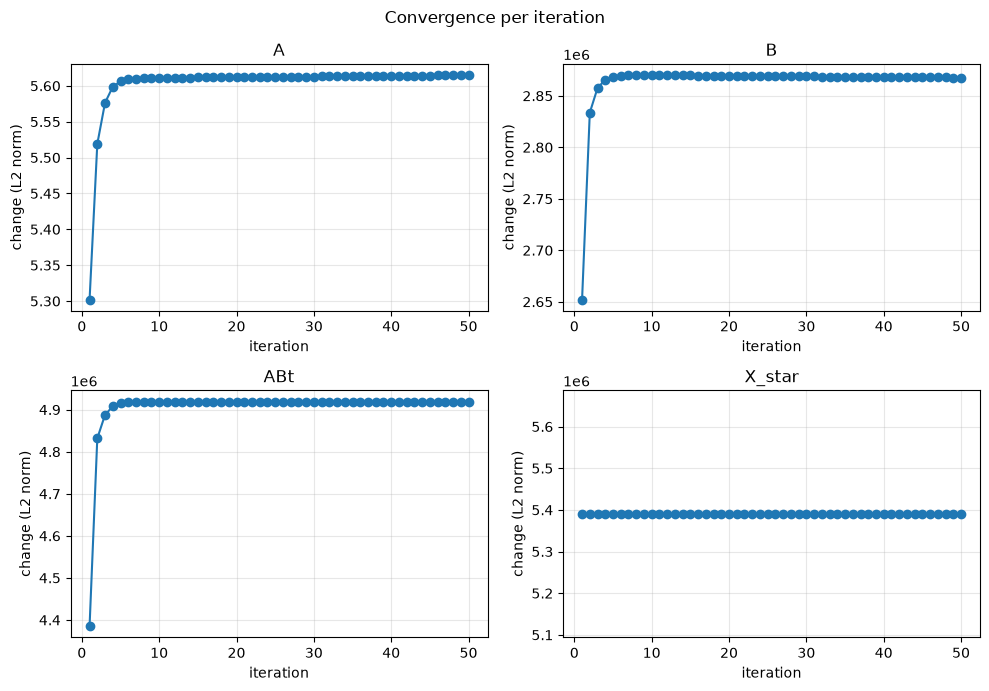

In [13]:
keys = ['A', 'B', 'ABt', 'X_star']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, k in zip(axes.flat, keys):
    vals = conv_vals[k]
    iters = range(1, len(vals) + 1)
    ax.plot(iters, vals, marker='o')
    ax.set_title(k)
    ax.set_xlabel('iteration')
    ax.set_ylabel('change (L2 norm)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Convergence per iteration')
fig.tight_layout()
plt.show()

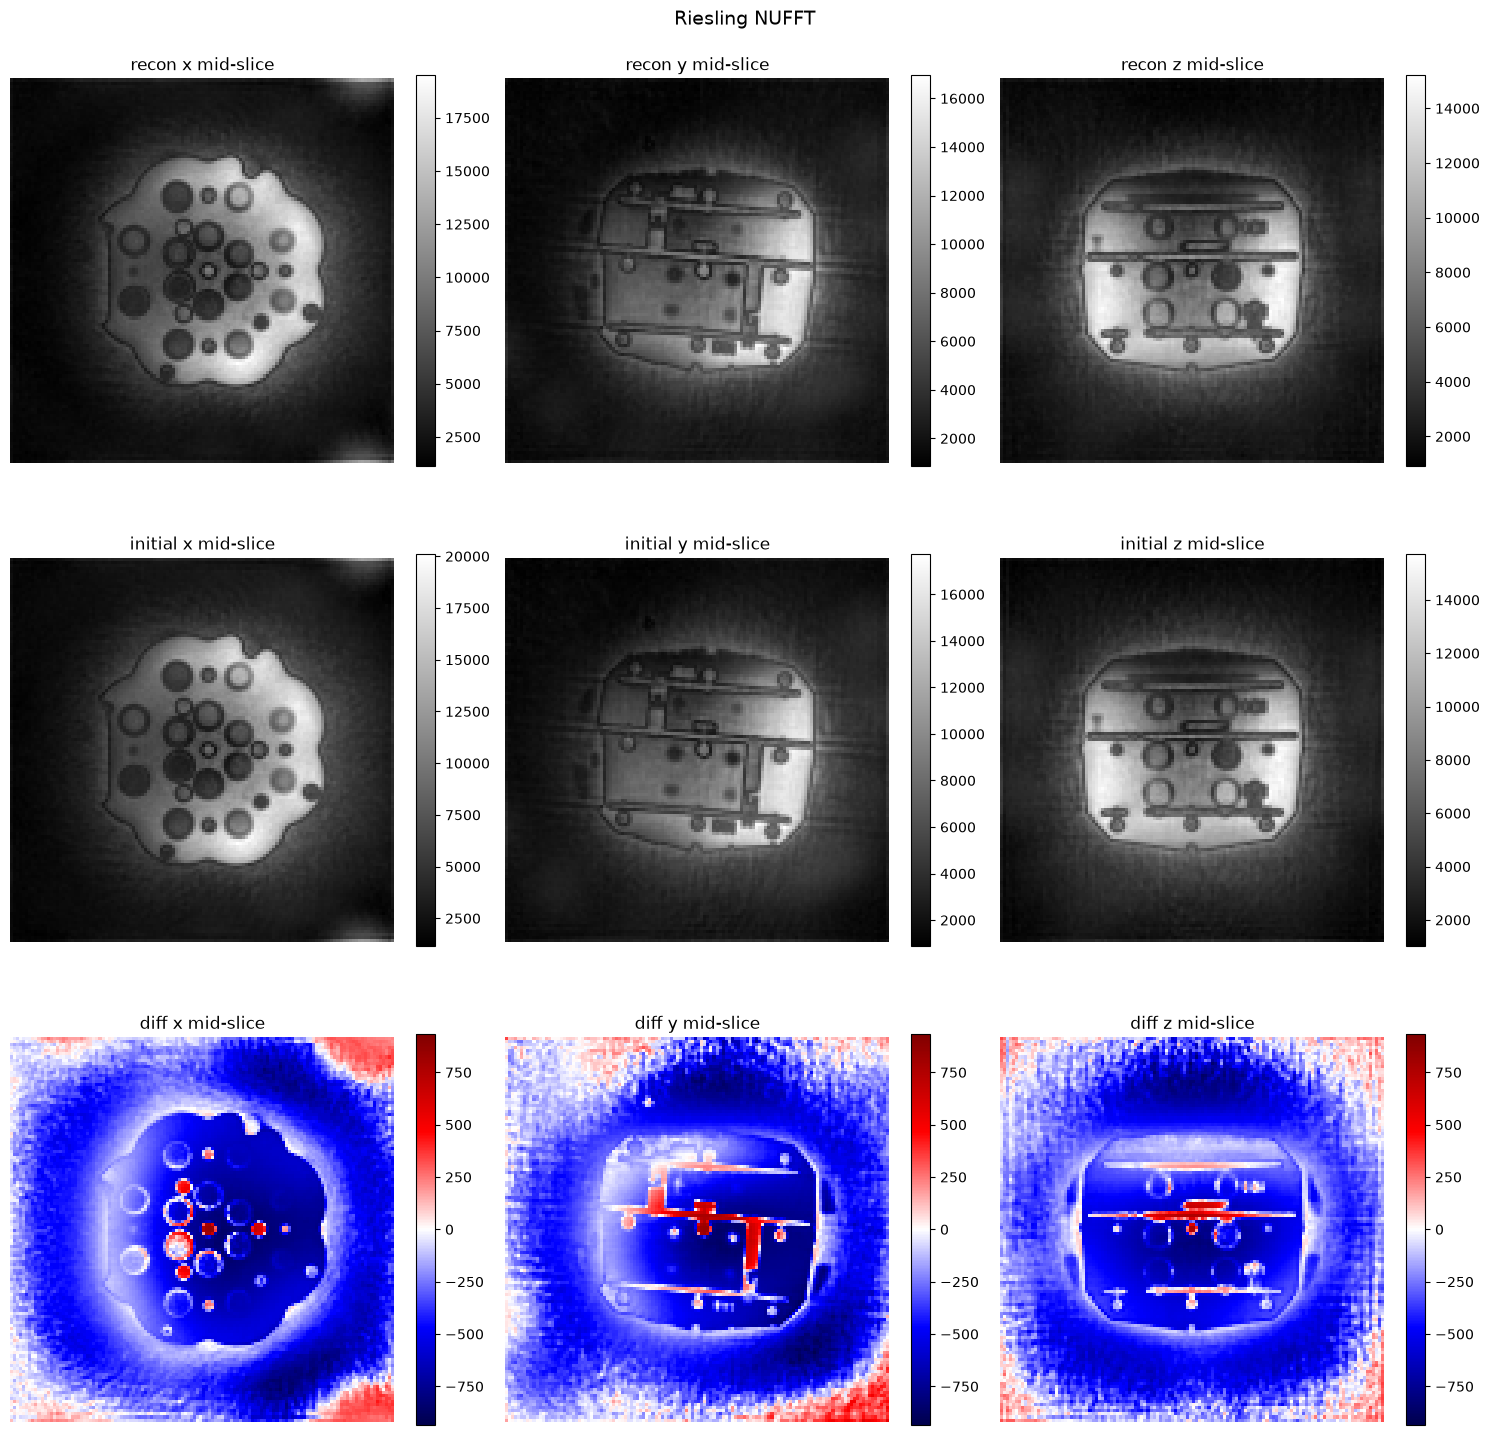

In [15]:
recon_rss = np.sum(np.abs(output)**2, axis=0)**0.5
ref_rss   = np.sum(np.abs(riesling_im)**2, axis=0)**0.5
diff_rss = recon_rss - ref_rss

nx, ny, nz = recon_rss.shape
slices = lambda v: [
    (v[nx // 2, :, :], 'x mid-slice'),
    (v[:, ny // 2, :], 'y mid-slice'),
    (v[:, :, nz // 2], 'z mid-slice'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Riesling NUFFT', fontsize=14)
rows = [('recon', recon_rss, 'gray'),
        ('initial',   ref_rss,   'gray'),
        ('diff',  diff_rss,  'seismic')]

for row_axes, (label, vol, cmap) in zip(axes, rows):
    vmax = np.abs(diff_rss).max() if label == 'diff' else None
    for ax, (sl, title) in zip(row_axes, slices(vol)):
        kw = dict(cmap=cmap)
        if label == 'diff':
            kw.update(vmin=-vmax, vmax=vmax)
        im = ax.imshow(sl, **kw) 
        ax.set_title(f'{label} {title}')
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.savefig('riesling_recon.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()